# 深度学习 HW02

学号：20234080324  
姓名：李英华

## 2 多层感知机

单隐层 MLP：

$$
H=\phi(XW_1+b_1),\qquad O=HW_2+b_2
$$

Sigmoid 与 tanh：

$$
\sigma(x)=\frac{1}{1+e^{-x}},\qquad \sigma'(x)=\sigma(x)(1-\sigma(x))
$$

$$
\tanh(x)=\frac{e^x-e^{-x}}{e^x+e^{-x}},\qquad \tanh'(x)=1-\tanh^2(x)
$$

In [1]:
import math
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset, TensorDataset

try:
    import torchvision
    from torchvision import transforms
except Exception:
    torchvision = None

import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})

print("运行设备:", device)

运行设备: cpu


In [2]:
def get_loaders(batch_size=256, train_limit=6000, val_limit=1000):
    if torchvision is not None:
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Lambda(lambda x: x.view(-1)),
        ])
        try:
            root = Path("./data")
            train_all = torchvision.datasets.FashionMNIST(
                root=root, train=True, download=True, transform=transform
            )
            test_all = torchvision.datasets.FashionMNIST(
                root=root, train=False, download=True, transform=transform
            )
            train_ds = Subset(train_all, range(min(train_limit, len(train_all))))
            val_ds = Subset(test_all, range(min(val_limit, len(test_all))))
            return (
                DataLoader(train_ds, batch_size=batch_size, shuffle=True),
                DataLoader(val_ds, batch_size=batch_size, shuffle=False),
                784,
                10,
                "Fashion-MNIST",
            )
        except Exception as exc:
            print("Fashion-MNIST 不可用，改用 sklearn digits 快速验证:", repr(exc))

    digits = load_digits()
    X = torch.tensor(digits.data / 16.0, dtype=torch.float32)
    y = torch.tensor(digits.target, dtype=torch.long)
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.25, random_state=SEED, stratify=y
    )
    train_ds = TensorDataset(X_train, y_train)
    val_ds = TensorDataset(X_val, y_val)
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True),
        DataLoader(val_ds, batch_size=batch_size, shuffle=False),
        X.shape[1],
        10,
        "sklearn digits",
    )


train_loader, val_loader, input_dim, num_classes, dataset_name = get_loaders()
print(f"数据集: {dataset_name} | train={len(train_loader.dataset)} | val={len(val_loader.dataset)} | input_dim={input_dim}")

数据集: Fashion-MNIST | train=6000 | val=1000 | input_dim=784


### 2.2 手写 MLP

只使用 Tensor 运算实现参数初始化、ReLU、Softmax 交叉熵与 mini-batch SGD。

In [3]:
def relu(X):
    return torch.clamp(X, min=0.0)


def softmax_cross_entropy(logits, y):
    shifted = logits - logits.max(dim=1, keepdim=True).values
    log_probs = shifted - torch.log(torch.exp(shifted).sum(dim=1, keepdim=True))
    return -log_probs[torch.arange(y.numel(), device=y.device), y].mean()


def accuracy(logits, y):
    return (logits.argmax(dim=1) == y).float().mean().item()


def init_mlp(input_dim, hidden_dim=128, num_classes=10, std=0.01):
    return [
        torch.normal(0, std, (input_dim, hidden_dim), device=device, requires_grad=True),
        torch.zeros(hidden_dim, device=device, requires_grad=True),
        torch.normal(0, std, (hidden_dim, num_classes), device=device, requires_grad=True),
        torch.zeros(num_classes, device=device, requires_grad=True),
    ]


def mlp_forward(X, params):
    W1, b1, W2, b2 = params
    H = relu(X @ W1 + b1)
    return H @ W2 + b2


def evaluate_manual(params):
    total_loss, total_acc, total_n = 0.0, 0.0, 0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            logits = mlp_forward(X, params)
            n = y.numel()
            total_loss += softmax_cross_entropy(logits, y).item() * n
            total_acc += accuracy(logits, y) * n
            total_n += n
    return total_loss / total_n, total_acc / total_n


params = init_mlp(input_dim, num_classes=num_classes)
lr, epochs = 0.2, 5
manual_history = {"train_loss": [], "val_loss": [], "val_acc": []}

for epoch in range(1, epochs + 1):
    total_loss, total_n = 0.0, 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        loss = softmax_cross_entropy(mlp_forward(X, params), y)
        loss.backward()
        with torch.no_grad():
            for p in params:
                p -= lr * p.grad
                p.grad.zero_()
        total_loss += loss.item() * y.numel()
        total_n += y.numel()

    val_loss, val_acc = evaluate_manual(params)
    manual_history["train_loss"].append(total_loss / total_n)
    manual_history["val_loss"].append(val_loss)
    manual_history["val_acc"].append(val_acc)
    print(f"epoch {epoch}: train_loss={total_loss/total_n:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

epoch 1: train_loss=1.9817, val_loss=1.4783, val_acc=0.4310
epoch 2: train_loss=1.1923, val_loss=0.9768, val_acc=0.6260
epoch 3: train_loss=0.9221, val_loss=0.8748, val_acc=0.6430
epoch 4: train_loss=0.8141, val_loss=0.7951, val_acc=0.6870
epoch 5: train_loss=0.7643, val_loss=0.9917, val_acc=0.6440


## 3 正则化

训练误差是模型在训练集上的平均损失；泛化误差是模型在真实数据分布上的期望损失。训练误差低但验证误差高，通常说明过拟合。

K 折交叉验证：把数据分为 $K$ 份，每次取 1 份验证、其余训练，重复 $K$ 次后取平均验证误差。

L2 更新：

$$
W\leftarrow(1-\eta\lambda)W-\eta\nabla_W L
$$

Dropout 训练时随机置零部分隐藏单元，并除以保留概率以保持期望不变；测试时关闭。

baseline | val_loss=0.7179 | val_acc=0.7360
L2       | val_loss=0.7790 | val_acc=0.6950
Dropout  | val_loss=0.6938 | val_acc=0.7430


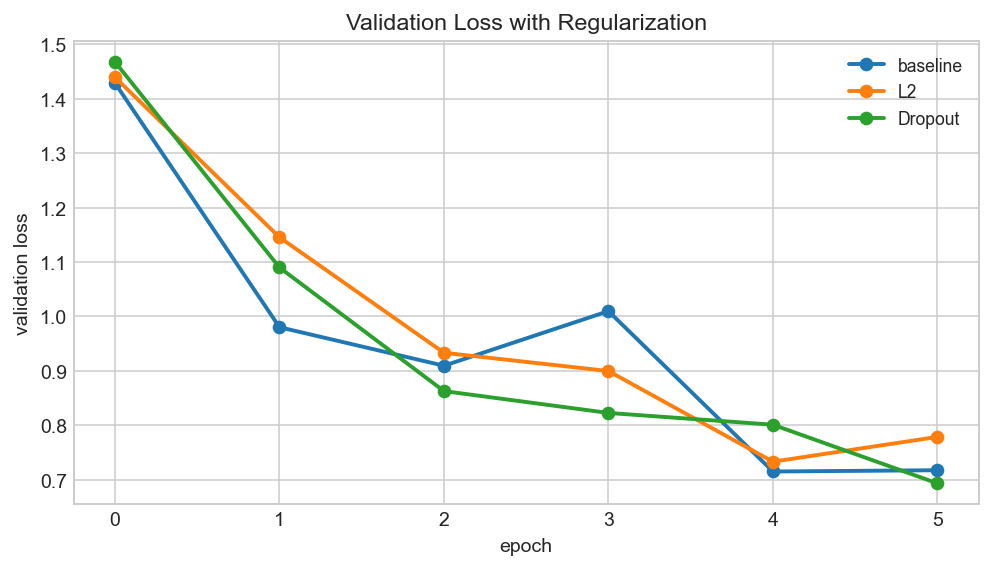

In [4]:
def dropout_layer(X, dropout, is_training=True):
    if (not is_training) or dropout == 0:
        return X
    if dropout == 1:
        return torch.zeros_like(X)
    mask = (torch.rand_like(X) > dropout).float()
    return mask * X / (1.0 - dropout)


def reg_forward(X, params, dropout=0.0, is_training=True):
    W1, b1, W2, b2 = params
    H = relu(X @ W1 + b1)
    H = dropout_layer(H, dropout, is_training)
    return H @ W2 + b2


def eval_reg(params, dropout=0.0):
    total_loss, total_acc, total_n = 0.0, 0.0, 0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            logits = reg_forward(X, params, dropout, is_training=False)
            n = y.numel()
            total_loss += softmax_cross_entropy(logits, y).item() * n
            total_acc += accuracy(logits, y) * n
            total_n += n
    return total_loss / total_n, total_acc / total_n


def train_reg(name, weight_decay=0.0, dropout=0.0, epochs=6, lr=0.2):
    params = init_mlp(input_dim, hidden_dim=128, num_classes=num_classes)
    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    for _ in range(epochs):
        total_loss, total_n = 0.0, 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            loss = softmax_cross_entropy(reg_forward(X, params, dropout, True), y)
            loss.backward()
            with torch.no_grad():
                W1, b1, W2, b2 = params
                W1 *= (1 - lr * weight_decay)
                W2 *= (1 - lr * weight_decay)
                for p in params:
                    p -= lr * p.grad
                    p.grad.zero_()
            total_loss += loss.item() * y.numel()
            total_n += y.numel()
        val_loss, val_acc = eval_reg(params, dropout)
        history["train_loss"].append(total_loss / total_n)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
    print(f"{name:8s} | val_loss={history['val_loss'][-1]:.4f} | val_acc={history['val_acc'][-1]:.4f}")
    return history


histories = {
    "baseline": train_reg("baseline", weight_decay=0.0, dropout=0.0),
    "L2": train_reg("L2", weight_decay=1e-3, dropout=0.0),
    "Dropout": train_reg("Dropout", weight_decay=0.0, dropout=0.5),
}

plt.figure()
for name, hist in histories.items():
    plt.plot(hist["val_loss"], marker="o", linewidth=2, label=name)
plt.xlabel("epoch")
plt.ylabel("validation loss")
plt.title("Validation Loss with Regularization")
plt.legend()
plt.tight_layout()

## 4 数值稳定性

深层网络反向传播会出现 Jacobian 连乘：

$$
\frac{\partial L}{\partial h_t}
=
\frac{\partial L}{\partial h_d}
\prod_{i=t}^{d-1}
\frac{\partial h_{i+1}}{\partial h_i}
$$

若连乘因子长期小于 1，梯度消失；长期大于 1，梯度爆炸。ReLU 在正区间导数为 1，配合合适初始化能缓解 sigmoid/tanh 饱和导致的梯度消失。

Sigmoid + N(0,1): loss=7.3378
ReLU + N(0,10): loss=NaN/Inf
Sigmoid + Xavier: loss=2.5256
ReLU + Kaiming: loss=2.7418
LeakyReLU + Kaiming: loss=2.7872


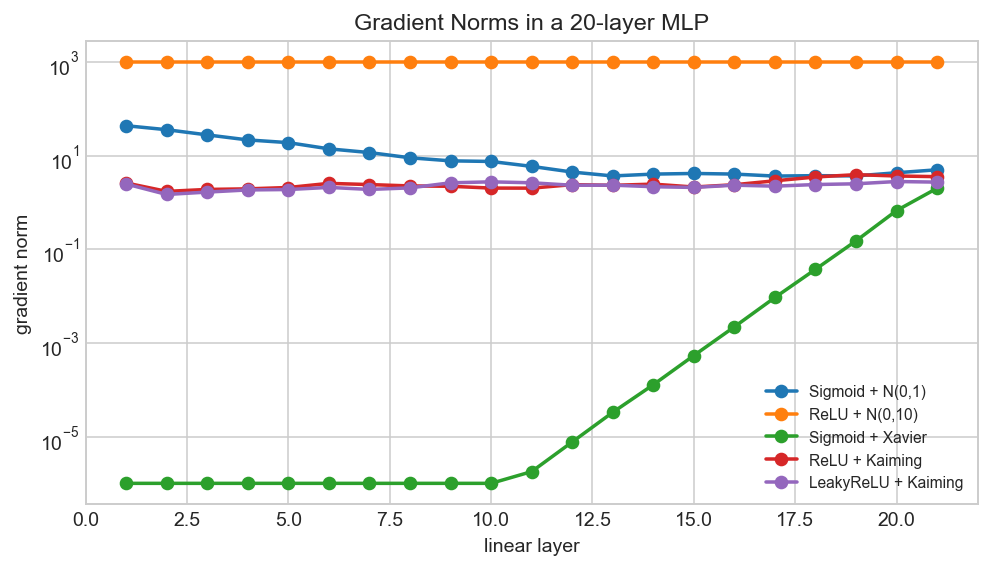

In [5]:
def make_deep_net(activation="sigmoid", hidden_dim=256, depth=20):
    layers, in_dim = [], input_dim
    for _ in range(depth):
        layers.append(nn.Linear(in_dim, hidden_dim))
        if activation == "sigmoid":
            layers.append(nn.Sigmoid())
        elif activation == "relu":
            layers.append(nn.ReLU())
        elif activation == "leaky_relu":
            layers.append(nn.LeakyReLU(0.01))
        in_dim = hidden_dim
    layers.append(nn.Linear(in_dim, num_classes))
    return nn.Sequential(*layers).to(device)


def init_deep(model, scheme):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            if scheme == "normal1":
                nn.init.normal_(m.weight, 0.0, 1.0)
            elif scheme == "normal10":
                nn.init.normal_(m.weight, 0.0, 10.0)
            elif scheme == "xavier":
                nn.init.xavier_uniform_(m.weight)
            elif scheme == "kaiming":
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            nn.init.zeros_(m.bias)


def grad_norms(label, activation, scheme):
    model = make_deep_net(activation)
    init_deep(model, scheme)
    X, y = next(iter(train_loader))
    X, y = X.to(device), y.to(device)
    loss = nn.CrossEntropyLoss()(model(X), y)
    if not torch.isfinite(loss):
        print(f"{label}: loss=NaN/Inf")
        return [1e3] * 21
    loss.backward()
    norms = []
    for m in model.modules():
        if isinstance(m, nn.Linear):
            g = m.weight.grad.detach().norm().item()
            norms.append(float(np.clip(g, 1e-6, 1e3)))
    print(f"{label}: loss={loss.item():.4f}")
    return norms


grad_results = {
    "Sigmoid + N(0,1)": grad_norms("Sigmoid + N(0,1)", "sigmoid", "normal1"),
    "ReLU + N(0,10)": grad_norms("ReLU + N(0,10)", "relu", "normal10"),
    "Sigmoid + Xavier": grad_norms("Sigmoid + Xavier", "sigmoid", "xavier"),
    "ReLU + Kaiming": grad_norms("ReLU + Kaiming", "relu", "kaiming"),
    "LeakyReLU + Kaiming": grad_norms("LeakyReLU + Kaiming", "leaky_relu", "kaiming"),
}

plt.figure()
for name, norms in grad_results.items():
    plt.plot(range(1, len(norms) + 1), norms, marker="o", linewidth=1.8, label=name)
plt.yscale("log")
plt.xlabel("linear layer")
plt.ylabel("gradient norm")
plt.title("Gradient Norms in a 20-layer MLP")
plt.legend(fontsize=8)
plt.tight_layout()

## 5 偏移数据

协变量偏移：

$$
p(x)\ne q(x),\qquad p(y|x)=q(y|x)
$$

标签偏移：

$$
p(y)\ne q(y),\qquad p(x|y)=q(x|y)
$$

协变量偏移可用重要性权重修正训练风险：

$$
w(x)=\frac{q(x)}{p(x)}
\approx
\frac{P(\mathrm{test}|x)}{P(\mathrm{train}|x)}
$$

普通回归 Q MSE: 0.2636
重要性加权 Q MSE: 0.2634
权重范围: [0.05, 20.00]


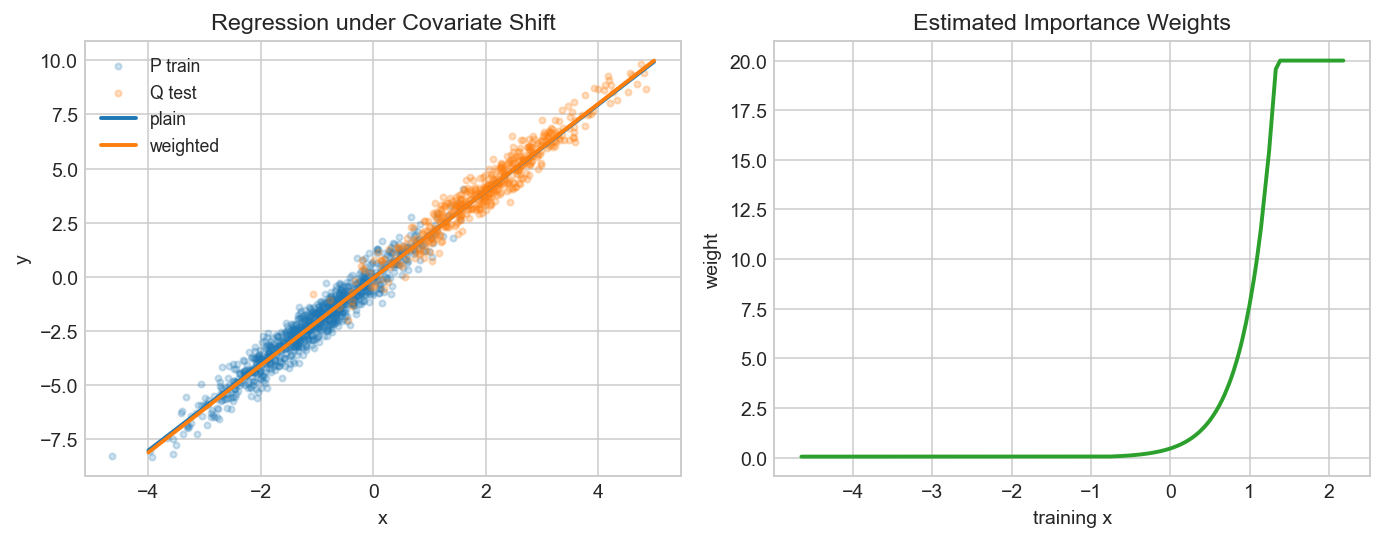

In [6]:
rng = np.random.default_rng(SEED)
n_train, n_test = 1000, 500
X_p = rng.normal(-1.0, 1.0, size=(n_train, 1))
y_p = 2 * X_p[:, 0] + rng.normal(0.0, 0.5, size=n_train)
X_q = rng.normal(2.0, 1.0, size=(n_test, 1))
y_q = 2 * X_q[:, 0] + rng.normal(0.0, 0.5, size=n_test)

plain_lr = LinearRegression().fit(X_p, y_p)
mse_plain = mean_squared_error(y_q, plain_lr.predict(X_q))

X_domain = np.vstack([X_p, X_q])
y_domain = np.r_[np.zeros(n_train), np.ones(n_test)]
domain_clf = LogisticRegression(random_state=SEED).fit(X_domain, y_domain)
proba = domain_clf.predict_proba(X_p)

weights = (n_train / n_test) * proba[:, 1] / np.maximum(proba[:, 0], 1e-6)
weights = weights / weights.mean()
weights = np.clip(weights, 0.05, 20.0)

weighted_lr = LinearRegression().fit(X_p, y_p, sample_weight=weights)
mse_weighted = mean_squared_error(y_q, weighted_lr.predict(X_q))

print(f"普通回归 Q MSE: {mse_plain:.4f}")
print(f"重要性加权 Q MSE: {mse_weighted:.4f}")
print(f"权重范围: [{weights.min():.2f}, {weights.max():.2f}]")

xs = np.linspace(-4, 5, 200).reshape(-1, 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(X_p[:, 0], y_p, s=10, alpha=0.22, label="P train")
axes[0].scatter(X_q[:, 0], y_q, s=10, alpha=0.25, label="Q test")
axes[0].plot(xs[:, 0], plain_lr.predict(xs), linewidth=2, label="plain")
axes[0].plot(xs[:, 0], weighted_lr.predict(xs), linewidth=2, label="weighted")
axes[0].set_title("Regression under Covariate Shift")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

order = np.argsort(X_p[:, 0])
axes[1].plot(X_p[order, 0], weights[order], linewidth=2, color="tab:green")
axes[1].set_title("Estimated Importance Weights")
axes[1].set_xlabel("training x")
axes[1].set_ylabel("weight")
plt.tight_layout()